## DERIVATIVE PRICING
MODULE 6 | LESSON 2


---


# **LOCAL VOLATILITY MODELS: DUPIRE**


|  |  |
|:---|:---|
|**Reading Time** |  50 minutes |
|**Prior Knowledge** | Volatility Smile, Local-volatility models, Implied volatility |
|**Keywords** | Volatility surface, Dupire model |


---


*In this lesson, we will dig deeper into the nature of the volatility smile and whether the implied volatility that option market prices exhibit is determined by more variables than just strikes.*<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

## 1. Implied Volatility Surface

In the previous lesson, you learned how to construct the volatility smile extracting data from traded option prices. However, in local volatility models such Dupire's, implied volatility from option prices is not expressed only as a function of moneyness (as in the Black-Scholes framework), but also depends on the maturity of the contract. This creates a three-dimensional dependence of implied volatility, and thus, we will move from a volatility smile to a volatility surface (3D).

The process is very similar to the previous one, with some peculiarities in terms of the amount of future maturities we consider, as well as the lessons we can learn from this exercise.

As always, let's begin by importing the necessary tools we'll need:

In [1]:
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

Just for comparative purposes, let's keep using the firm IBM as the focus of our investigation of volatility surface. Let's first look at the future expiration dates in the options chain data:

In [2]:
chain = pd.read_excel("Options_chain_mats.xlsx", sheet_name=['Calls', 'Puts'])
df_call=chain['Calls']
df_put=chain['Puts']
price = 214.23

Next, let's extract and handle the data to organize it properly:

In [3]:
today = pd.to_datetime('2024-11-11')
df_call['Maturity'] = pd.to_datetime(df_call['Maturity'], format='%Y-%m-%d')
df_put['Maturity'] = pd.to_datetime(df_put['Maturity'], format='%Y-%m-%d')

df_call['Days to maturity'] = (df_call['Maturity'] - today).dt.days
df_put['Days to maturity'] = (df_put['Maturity'] - today).dt.days

In [4]:
df_call

,Contract Name,Strike,Last Price,Bid,Ask,Change,% Change,Volume,Open Interest,Implied Volatility,Maturity,Days to maturity
0,IBM241129C00145000,145,74.40,68.30,71.40,0.00,0.0000,-,1,0.9531,2024-11-29,18
1,IBM241129C00150000,150,65.19,64.30,66.60,0.00,0.0000,1,1,1.0242,2024-11-29,18
2,IBM241129C00160000,160,46.58,53.35,55.65,0.00,0.0000,-,2,0.6270,2024-11-29,18
3,IBM241129C00175000,175,39.70,38.25,41.50,-17.95,-0.3114,-,7,0.5562,2024-11-29,18
4,IBM241129C00190000,190,17.82,24.30,25.00,0.00,0.0000,-,15,0.3857,2024-11-29,18
...,...,...,...,...,...,...,...,...,...,...,...,...
70,IBM241220C00300000,300,0.20,0.00,0.35,0.00,0.0000,3,34,0.5073,2024-12-20,39
71,IBM241220C00310000,310,0.31,0.00,0.38,0.00,0.0000,-,3,0.5015,2024-12-20,39
72,IBM241220C00315000,315,0.31,0.00,0.37,0.00,0.0000,-,1,0.5176,2024-12-20,39
73,IBM241220C00320000,320,0.28,0.00,0.37,0.00,0.0000,-,4,0.5352,2024-12-20,39


Finally, after some small modifications, we can plot the data and construct our volatility surface. 

Notice that in the following code snippet we are defining **moneyness** as $Log(K/S_t)$, so a moneyness of 0 refers to the ATM point.

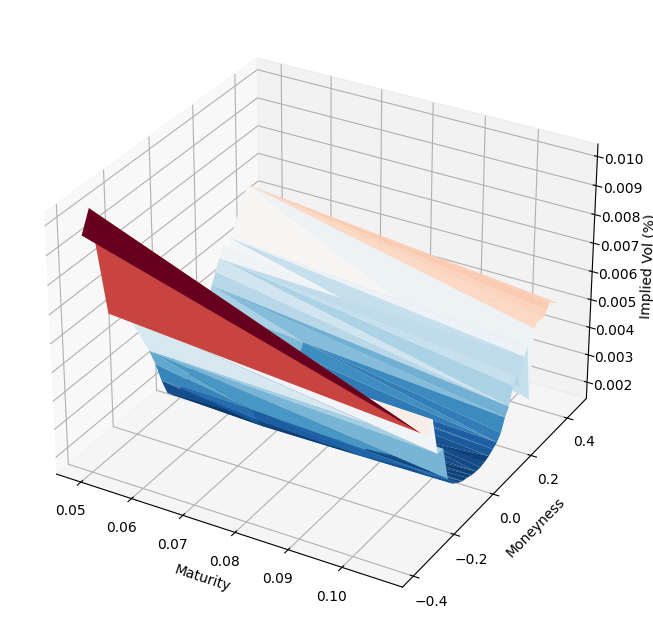

In [5]:
callData = df_call

callData = callData[callData['Implied Volatility']<90]
callData = callData[callData['Implied Volatility']>0]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_trisurf(callData['Days to maturity']/365, np.log(callData['Strike']/price), callData['Implied Volatility']/100, cmap=plt.cm.RdBu_r, linewidth=0)

# set axis labels
ax.set_xlabel('Maturity')
ax.set_ylabel('Moneyness')
ax.set_zlabel('Implied Vol (%)')

plt.show()



## 2. Conclusion

Now you know how to handle data to construct an implied volatility surface. If you have played around with the previous strike prices, you will have realized that the availability of options with different strikes decreases as we move away from the ATM strike. In other words, near ATM, there are options available for a wide range of strikes with little increments from one another. When we move away from this point, there are larger differences between one option's strike and the strike of the next available one. This produces certain spikes in the volatility surface, making it less smooth than sometimes desirable (e.g., we want to price an exotic option for which there is no observable strike and, thus, implied volatility).

**What can we do about this in practice?**

In practice, if you want a smoother ("more continuous") volatility surface, you will need to interpolate the volatility surface. This can become a tedious and complex process. The literature has proposed several methods to do this, although this is out of the scope of the current course. If you want to learn more about it, you can take a look at the following papers (these are **not** required readings):

- Avellaneda, Marco, et al. "Calibrating Volatility Surfaces via Relative-Entropy Minimization." *Applied Mathematical Finance*, vol. 4, no. 1, 1997, pp. 37–64.

- Fengler, Matthias R. "Arbitrage-Free Smoothing of the Implied Volatility Surface." *Quantitative Finance*, vol. 9, no. 4, 2009, pp. 417–428.


---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
